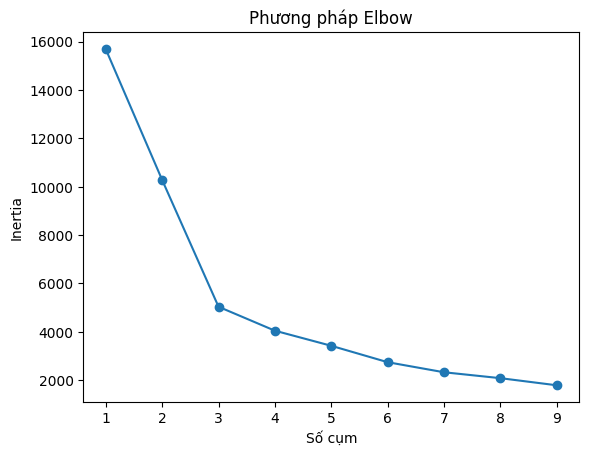

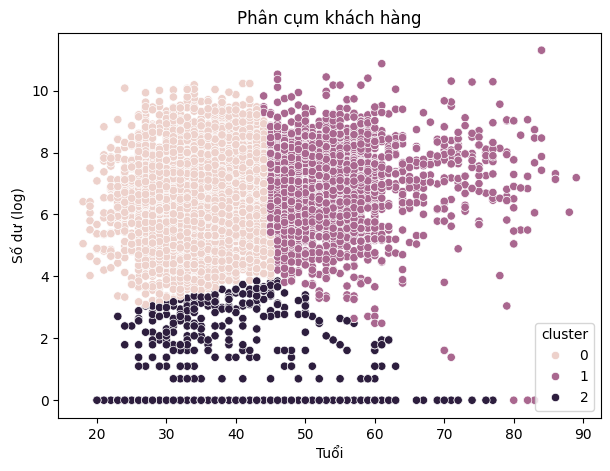

               age  balance_log
cluster                        
0        34.320771     6.604876
1        54.985775     6.885257
2        40.395210     0.550582


In [1]:
# ==============================
# CUSTOMER SEGMENTATION (KMEANS)
# ==============================

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = pd.read_csv("../data/processed/data_processed.csv")

# chọn feature
features = ["age", "balance_log"]

X = data[features]

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# ELBOW METHOD
# ==============================

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker="o")
plt.title("Phương pháp Elbow")
plt.xlabel("Số cụm")
plt.ylabel("Inertia")
plt.show()

# ==============================
# TRAIN KMEANS
# ==============================

kmeans = KMeans(n_clusters=3, random_state=42)
data["cluster"] = kmeans.fit_predict(X_scaled)

# ==============================
# VISUALIZE
# ==============================

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=data["age"],
    y=data["balance_log"],
    hue=data["cluster"]
)

plt.title("Phân cụm khách hàng")
plt.xlabel("Tuổi")
plt.ylabel("Số dư (log)")
plt.show()

# ==============================
# PHÂN TÍCH CLUSTER
# ==============================

cluster_summary = data.groupby("cluster")[features].mean()

print(cluster_summary)